In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [21]:
sns.set()
df = pd.read_csv("StudentsPerformance.csv")

**First 7 Rows of the Dataset**

In [22]:
df.head(7)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92


**Type of Columns in the Dataset**

In [23]:
df.dtypes

gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

**Checking for the Existence of Missing Values**

In [24]:
print(df.isna().sum())

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


**Checking If there are Duplicate Rows**

In [25]:
df.duplicated()[df.duplicated()==True]

Series([], dtype: bool)

**Total No. Rows & Colums in the Dataset**

In [26]:
print("Shape (rows, columns): ", df.shape,"\n")
print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (1000, 8) 

number of rows:  1000
number of columns:  8


**Overall Descriptive Summary**

In [43]:
df.describe(include='all')

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
count,1000,1000,1000,1000,1000,1000.00000,1000.000000,1000.000000
unique,2,5,6,2,2,NaN,NaN,NaN
top,female,group C,some college,standard,none,NaN,NaN,NaN
freq,518,319,226,645,642,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,66.08900,69.169000,68.054000
std,NaN,NaN,NaN,NaN,NaN,15.16308,14.600192,15.195657
min,NaN,NaN,NaN,NaN,NaN,0.00000,17.000000,10.000000
25%,NaN,NaN,NaN,NaN,NaN,57.00000,59.000000,57.750000
50%,NaN,NaN,NaN,NaN,NaN,66.00000,70.000000,69.000000
75%,NaN,NaN,NaN,NaN,NaN,77.00000,79.000000,79.000000


**Distribution of Math Scores in general**

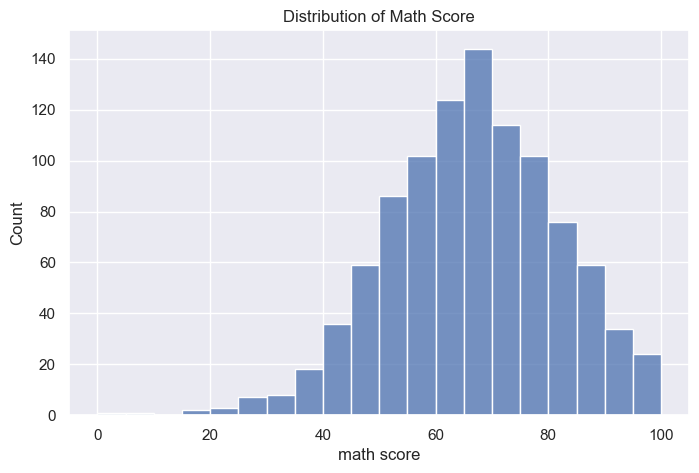

In [28]:
plt.figure(figsize=(8,5))
sns.histplot(df['math score'], bins=20)
plt.title("Distribution of Math Score")
plt.show()

Most scores are located in the middle, meaning that most of students have an average performance. Very few students scored extremely low or extremely high, suggesting that its a normal distribution.

**Scatter plot of Math Scores & Reading Scores**

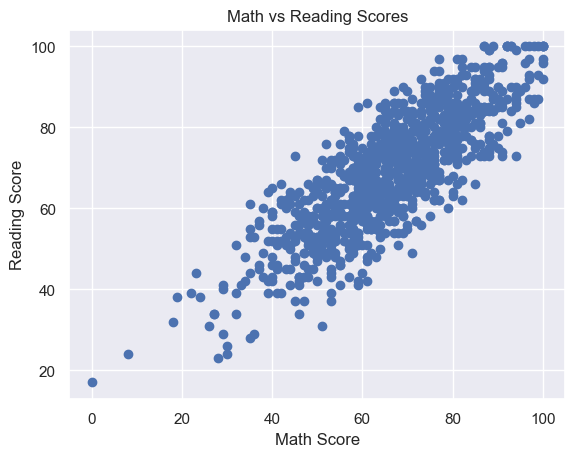

In [30]:
plt.scatter(df["math score"], df["reading score"])
plt.xlabel("Math Score")
plt.ylabel("Reading Score")
plt.title("Math vs Reading Scores")
plt.show()

Scatter plot that shows the positive relationship between math and reading scores.if students scored high in math; then it's very likely that they'll also score high in reading.

**Average Math Score for Both Genders**

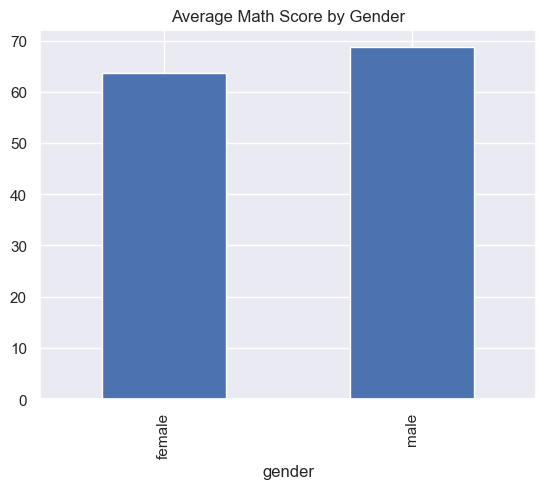

In [31]:
df.groupby("gender")["math score"].mean().plot(kind="bar")
plt.title("Average Math Score by Gender")
plt.show()

This plot compares the mean math score across genders. Shows whether one group has a higher average math score, and as can be seen, Males score higher. (difference in average performance, not individual variation)

**Correlation Between Exam Scores**

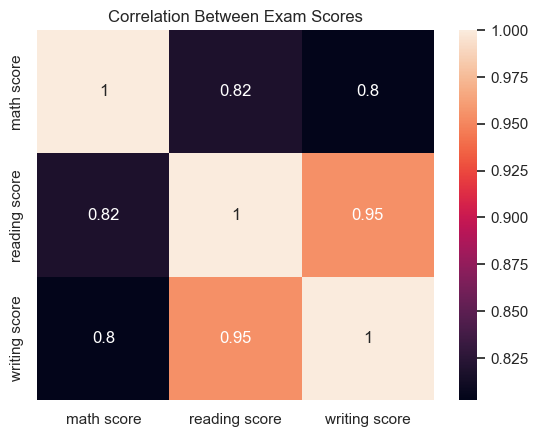

In [33]:
numeric_df = df.select_dtypes(include=["number"])
plt.figure()
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Between Exam Scores")
plt.show()

shows how strongly the scores move together (reading/writing usually correlate strongly).

**Reading Score Box Plot Distribution**

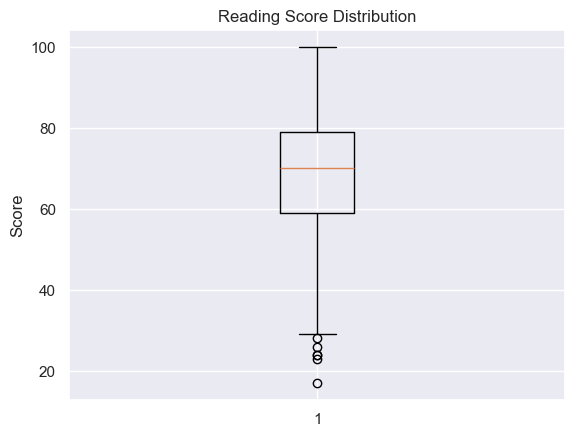

In [34]:
plt.boxplot(df["reading score"])
plt.title("Reading Score Distribution")
plt.ylabel("Score")
plt.show()

The boxplot shows the spread of reading scores. It highlights the median, quartiles, and potential outliers. The presence of outliers means that some students performed significantly differently from the overall group.

**The Effect that test preparation has on the Studnets score**

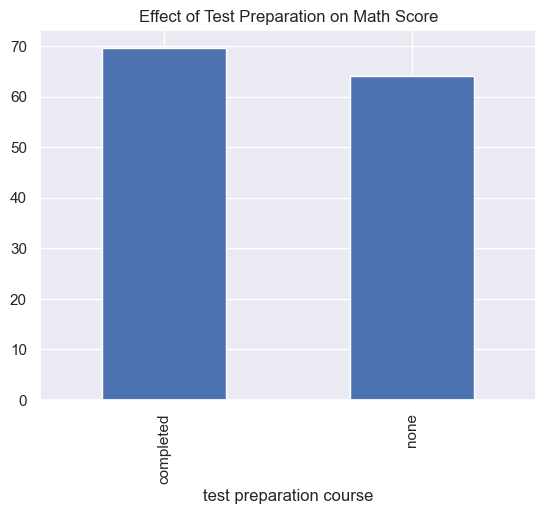

In [35]:
df.groupby("test preparation course")["math score"].mean().plot(kind="bar")
plt.title("Effect of Test Preparation on Math Score")
plt.show()

This highlights the impact of completing a test preparation course on student performance. It's clear that students who completed the preparation course achieved higher average scores compared to those who did not, suggesting that preparation positively influences exam results.

**Average scores for both Females and Males**

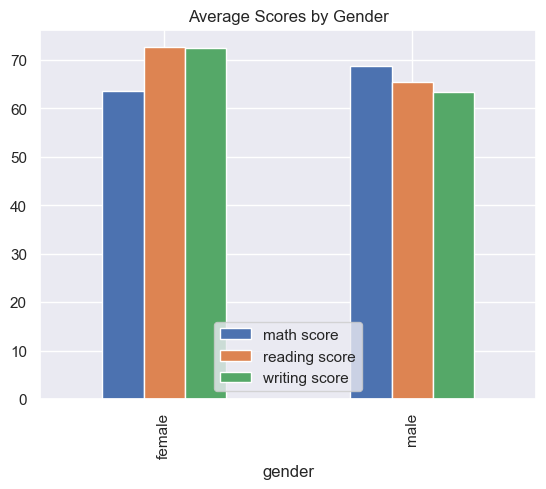

In [42]:
df.groupby("gender")[["math score","reading score","writing score"]].mean().plot(kind="bar")
plt.title("Average Scores by Gender")
plt.show()

This bar chart compares the average exam scores between genders. It helps identify performance differences across subjects. It shows that one gender slightly outperforms the other in some subjects, indicating possible variation in academic strengths. 

**Scatter Plot of Reading VS. Writing Scores**

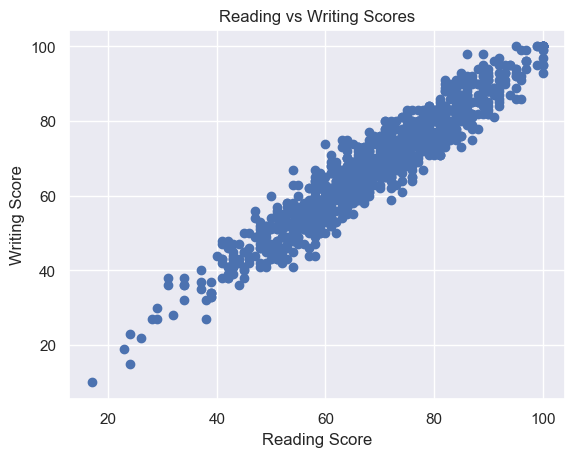

In [44]:
plt.scatter(df["reading score"], df["writing score"])
plt.xlabel("Reading Score")
plt.ylabel("Writing Score")
plt.title("Reading vs Writing Scores")
plt.show()